# Analiza rentowności potencjalnej farmy wiatrowej na Półwyspie Helskim, z użyciem symulacji Monte Carlo.

In [1]:
import pygrib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import weibull_min
from scipy.special import ndtr

In [2]:
BASE_SEED = 420
BASE_RNG = np.random.default_rng(BASE_SEED)

## Model wiatru

W pliku `heldata.grib` znajdują się historyczne (2025, 2026) dane o wietrze na Półwyspie Helskim. Pobrane z https://cds.climate.copernicus.eu

In [3]:
data = []

with pygrib.open('heldata.grib') as grbs:
    times_data = {}
    
    for grb in grbs:
        valid_time = grb.validDate
        key = valid_time
        
        if key not in times_data:
            times_data[key] = {'U': None, 'V': None}
            
        val = np.mean(grb.values)
        
        if 'U wind' in grb.name:
            times_data[key]['U'] = val
        elif 'V wind' in grb.name:
            times_data[key]['V'] = val

historical_wind_data = pd.DataFrame.from_dict(times_data, orient='index')
historical_wind_data.index.name = 'time'
historical_wind_data.reset_index(inplace=True)

historical_wind_data['speed'] = np.sqrt(historical_wind_data['U']**2 + historical_wind_data['V']**2)
historical_wind_data['direction'] = (np.degrees(np.arctan2(historical_wind_data['U'], historical_wind_data['V'])) + 360) % 360

print(historical_wind_data.head())

                 time          U         V      speed  direction
0 2025-01-01 00:00:00  10.043070  8.199020  12.964845  50.772287
1 2025-01-01 01:00:00  10.283498  8.701040  13.470650  49.764882
2 2025-01-01 02:00:00  11.203974  8.561264  14.100507  52.615563
3 2025-01-01 03:00:00  11.946437  8.730352  14.796499  53.840991
4 2025-01-01 04:00:00  13.491776  9.060969  16.252051  56.115005


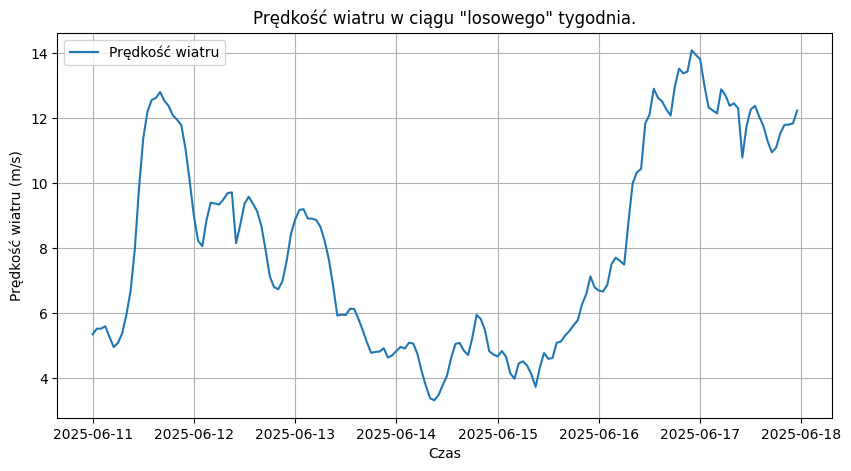

In [4]:
plt.figure(figsize=(10, 5))
plt.plot(historical_wind_data['time'][3864:3864+168], historical_wind_data['speed'][3864:3864+168], label='Prędkość wiatru')
plt.xlabel('Czas')
plt.ylabel('Prędkość wiatru (m/s)')
plt.title("Prędkość wiatru w ciągu \"losowego\" tygodnia.")
plt.legend()
plt.grid()
plt.show()

Na podstawie pobranych danych historycznych dobieramy parametry $\lambda$ i $k$ (shape) dla rozkładu Weibulla, przy pomocy którego będę symulować moc wiatru. 

In [5]:
k, _, lam = weibull_min.fit(historical_wind_data['speed'], floc=0)
print(f"Weibull parameters: \n\tk = {k}, \n\tlambda = {lam}.")

Weibull parameters: 
	k = 2.34032382485511, 
	lambda = 8.83383442377965.


In [6]:
def simulate_wind_speeds(k, lam, num_samples = 24, num_sims = 1, seed = BASE_SEED, rng = BASE_RNG):
    if rng is None:
        rng = np.random.default_rng(seed)

    wind_samples = lam * rng.weibull(k, (num_samples, num_sims))
    
    return wind_samples

### Przykłądowe próbki wiatru

In [7]:
wind_samples = simulate_wind_speeds(k, lam, 8760)

In [8]:
helwind2025 = historical_wind_data['speed'][:8760]

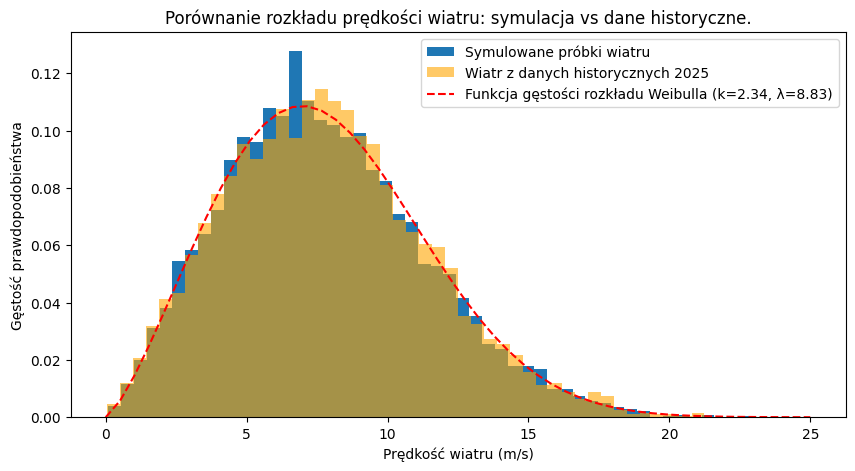

In [9]:
plt.figure(figsize=(10, 5))
plt.hist(wind_samples, bins=50, density=True, label='Symulowane próbki wiatru')
plt.hist(helwind2025, bins=50, density=True, color='orange', alpha=0.6, label='Wiatr z danych historycznych 2025')
plt.plot(np.linspace(0, 25, 50), weibull_min.pdf(np.linspace(0, 25, 50), k, scale=lam), 'r--', label=f'Funkcja gęstości rozkładu Weibulla (k={k:.2f}, λ={lam:.2f})')
plt.title("Porównanie rozkładu prędkości wiatru: symulacja vs dane historyczne.")
plt.xlabel('Prędkość wiatru (m/s)')
plt.ylabel('Gęstość prawdopodobieństwa')
plt.legend()
plt.show()


Aby symulowane dane wiatrowe bardziej przypominały rzeczywiste pomiary, dodać można autokorelację czasową za pomocą procesu AR(1). Dzięki temu unikamy nienaturalnych, gwałtownych skoków prędkości między sąsiednimi próbkami.

In [10]:
def simulate_autocorelated_wind_speeds(k, lam, rho = 0.7, num_samples = 24, num_sims = 1, seed = BASE_SEED, rng = BASE_RNG):
    if rng is None:
        rng = np.random.default_rng(seed)
        
    noise = rng.standard_normal((num_samples, num_sims))
    
    z = np.zeros((num_samples, num_sims))
    z[0] = noise[0]
    noise_scale = np.sqrt(1 - rho**2)
    
    for t in range(1, num_samples):
        z[t] = rho * z[t-1] + noise_scale * noise[t]
        
    unitary = ndtr(z)
    
    wind_ar1 = lam * (- np.log(1 - unitary))**(1/k)
    
    return wind_ar1

### Porównanie wykresów wiatru: niezależnego i z autokorelacją

In [11]:
autocorelated_wind_samples = simulate_autocorelated_wind_speeds(k, lam, num_samples=8760)

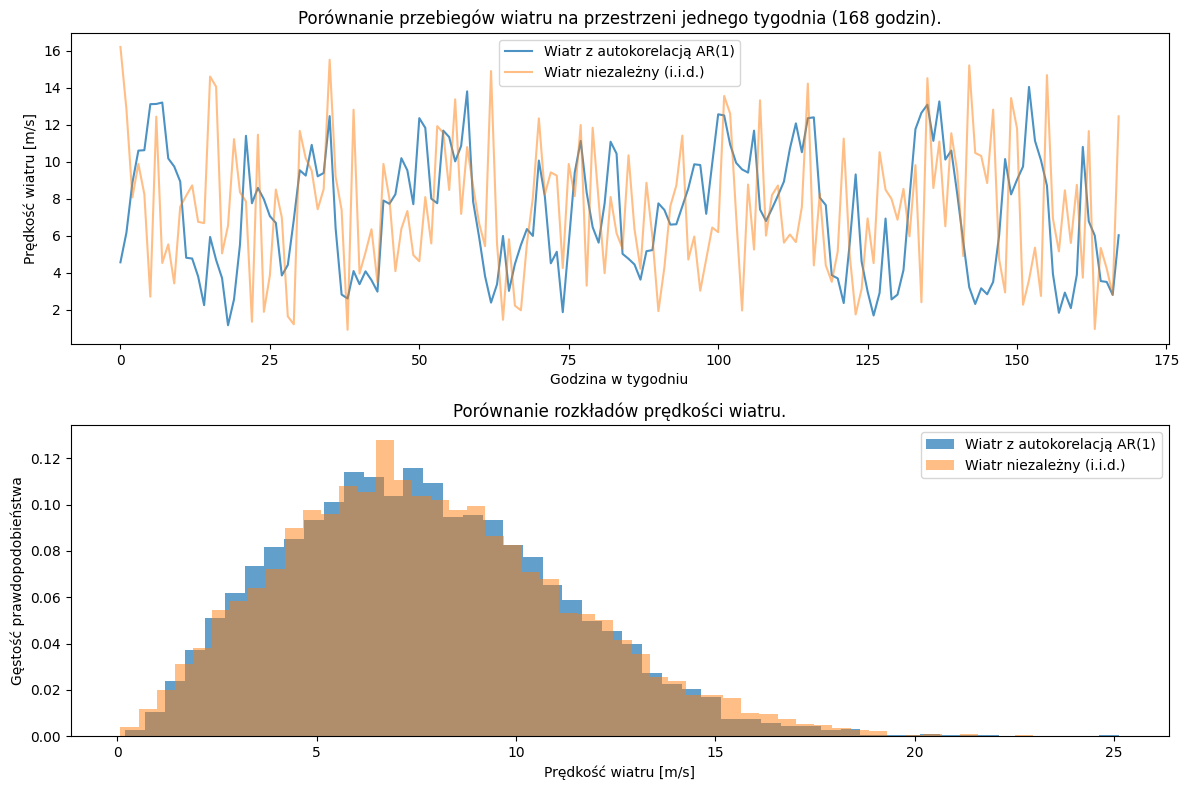

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# axes[0].figure(figsize=(12, 4))
axes[0].plot(autocorelated_wind_samples[:168], label='Wiatr z autokorelacją AR(1)', alpha=0.8)
axes[0].plot(wind_samples[:168], label='Wiatr niezależny (i.i.d.)', alpha=0.5)
axes[0].set_xlabel('Godzina w tygodniu')
axes[0].set_ylabel('Prędkość wiatru [m/s]')
axes[0].set_title('Porównanie przebiegów wiatru na przestrzeni jednego tygodnia (168 godzin).')
axes[0].legend()

# axes[1].figure(figsize=(12, 4))
axes[1].hist(autocorelated_wind_samples, bins=50, density=True, alpha=0.7, label='Wiatr z autokorelacją AR(1)')
axes[1].hist(wind_samples, bins=50, density=True, alpha=0.5, label='Wiatr niezależny (i.i.d.)')
axes[1].set_xlabel('Prędkość wiatru [m/s]')
axes[1].set_ylabel('Gęstość prawdopodobieństwa')
axes[1].set_title('Porównanie rozkładów prędkości wiatru.')
axes[1].legend()

plt.tight_layout()
plt.show()

## Model zmian cen energii
W pliku `energy-production-spot-poland.csv` znajdują się historyczne (2025) dane o cenie energii w Polsce. Pobrane z https://energy-charts.info

In [13]:
df = pd.read_csv(
    'energy-production-spot-poland.csv', 
    skiprows=1
    )
df.columns = ['datetime', 'non_renawable_mw', 'renawable_mw', 'price_eur/mwh']
df['datetime'] = pd.to_datetime(df['datetime'], utc=True)
df.set_index('datetime', inplace=True)

energy_prices_hourly = df['price_eur/mwh'].dropna()
energy_prices_daily = energy_prices_hourly.resample('D').mean()


energy_prices_daily.tail()

datetime
2025-12-27 00:00:00+00:00     92.626979
2025-12-28 00:00:00+00:00     89.665208
2025-12-29 00:00:00+00:00     98.631667
2025-12-30 00:00:00+00:00     84.067917
2025-12-31 00:00:00+00:00    105.465326
Freq: D, Name: price_eur/mwh, dtype: float64

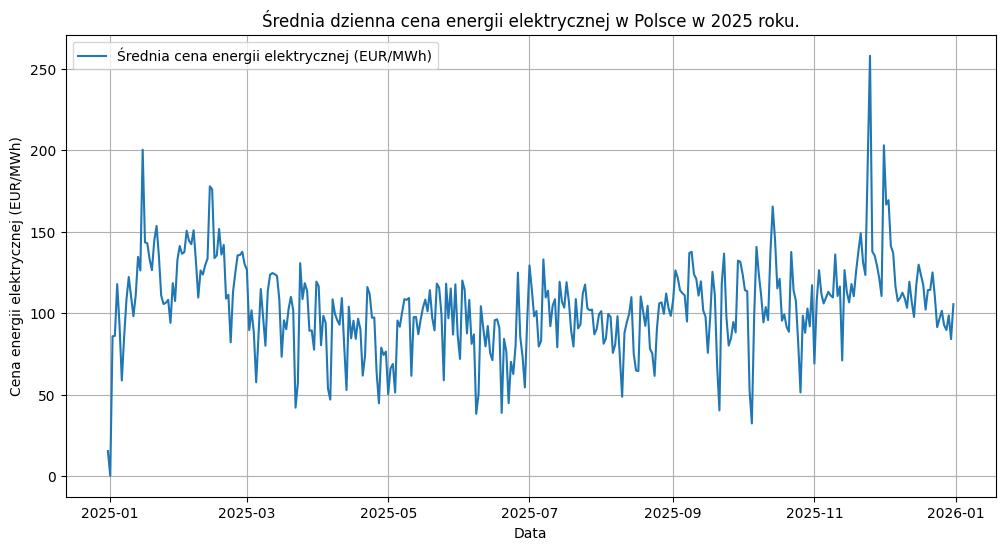

In [14]:
plt.figure(figsize=(12, 6))
plt.plot(energy_prices_daily.index, energy_prices_daily.values, linestyle='-', label='Średnia cena energii elektrycznej (EUR/MWh)')
plt.xlabel('Data')
plt.ylabel('Cena energii elektrycznej (EUR/MWh)')
plt.title('Średnia dzienna cena energii elektrycznej w Polsce w 2025 roku.')
plt.legend()
plt.grid()
plt.show()

### Proces Ornsteina-Uhlenbecka
$$
dX_t = \theta(\mu - X_t)dt + \sigma dW_t,
$$

Niech $t_n = nh$, wtedy metoda Eulera-Maruyamy daje postać:
$$
X_{n+1} = X_n + \theta(\mu - X_t)h + \sigma \sqrt{h} \,\epsilon_t
$$
$$
X_{n+1} = X_n + \theta\mu h - \theta X_t h + \sigma \sqrt{h}\,\epsilon_t
$$
$$
X_{n+1} = \theta\mu h + (1 - \theta h)X_n + \sigma \sqrt{h}\,\epsilon_t
$$

Otrzymujemy regresję liniową:
$$
X_{n+1} = aX_t + b + \eta_t,
$$
gdzie: $a=1-\theta h$, $b=\theta \mu h$, $\eta_t \sim \mathcal{N}(0, \sigma^2h)$.


In [15]:
train_todays = energy_prices_daily[:int(0.6*len(energy_prices_daily))]
train_tommorows = energy_prices_daily[1:int(0.6*len(energy_prices_daily))+1]

a, b = np.polyfit(train_todays, train_tommorows, 1)

### Parametry do symulacji O-U
$$ \theta = \frac{1-a}{h} $$

$$ \mu = \frac{b}{\theta h} = \frac{b}{1-a} $$

$$ \text{Var}(\eta) = \sigma^2h \Rightarrow \sigma = \frac{\sqrt{\text{Var}(\eta)}}{\sqrt{h}} $$

$ t = 1,\quad n = 365,\quad h = \frac{1}{365} $

In [16]:
predicted_tommorows = a * train_todays + b
differences = train_tommorows - predicted_tommorows

variance = np.var(differences, ddof=2)

h = 1/365

theta = (1-a) / h
mu = b / (1-a)
sigma = np.sqrt(variance / h)

print("\033[1mWyniki modelu regresji liniowej\033[0m")
print(f"Współczynnik kierunkowy (a): {a:.4f}")
print(f"Wyraz wolny (b):             {b:.4f}")
print(f"Wariancja szumu Var(eta):    {variance:.4f}\n")

print("\033[1mEstymowane parametry O-U\033[0m")
print(f"Szybkość powrotu (Theta):    {theta:.4f}")
print(f"Średnia długoterminowa (Mu): {mu:.4f}")
print(f"Zmienność procesu (Sigma):   {sigma:.4f}")


Wyniki modelu regresji liniowej
Współczynnik kierunkowy (a): 0.6003
Wyraz wolny (b):             40.5143
Wariancja szumu Var(eta):    117.8666

Estymowane parametry O-U
Szybkość powrotu (Theta):    145.8862
Średnia długoterminowa (Mu): 101.3648
Zmienność procesu (Sigma):   207.4158


Do procesu Ornsteina-Uhlenbecka dodaję jeszcze jump diffusion (parametry dobrałem "na oko"), aby bardziej odwzorować nieregularność rynku enrergii.

In [17]:
def simulate_energy_prices(theta, mu, sigma, n, h, x0=None, jump_std=42, num_sims=1, seed=BASE_SEED, rng = BASE_RNG):
    if rng is None:
        rng = np.random.default_rng(seed)
        
    sim_prices = np.zeros((n, num_sims))
    sim_prices[0] = x0 if x0 is not None else mu
        
    for t in range(1, n):
        drift = theta * (mu - sim_prices[t-1]) * h
        diffusion = sigma * np.sqrt(h) * rng.normal(size = num_sims)
    
        num_jumps = rng.poisson(15*h, size=num_sims)
        jump = rng.normal(0, 42*np.sqrt(num_jumps), size=num_sims)

        sim_prices[t] = sim_prices[t-1] + drift + diffusion + jump
    
    return sim_prices

### Przykładowe próbki cen energii

In [18]:
n = 365
num_sims = 10

sim_prices = simulate_energy_prices(theta, mu, sigma, n, h, num_sims=num_sims)

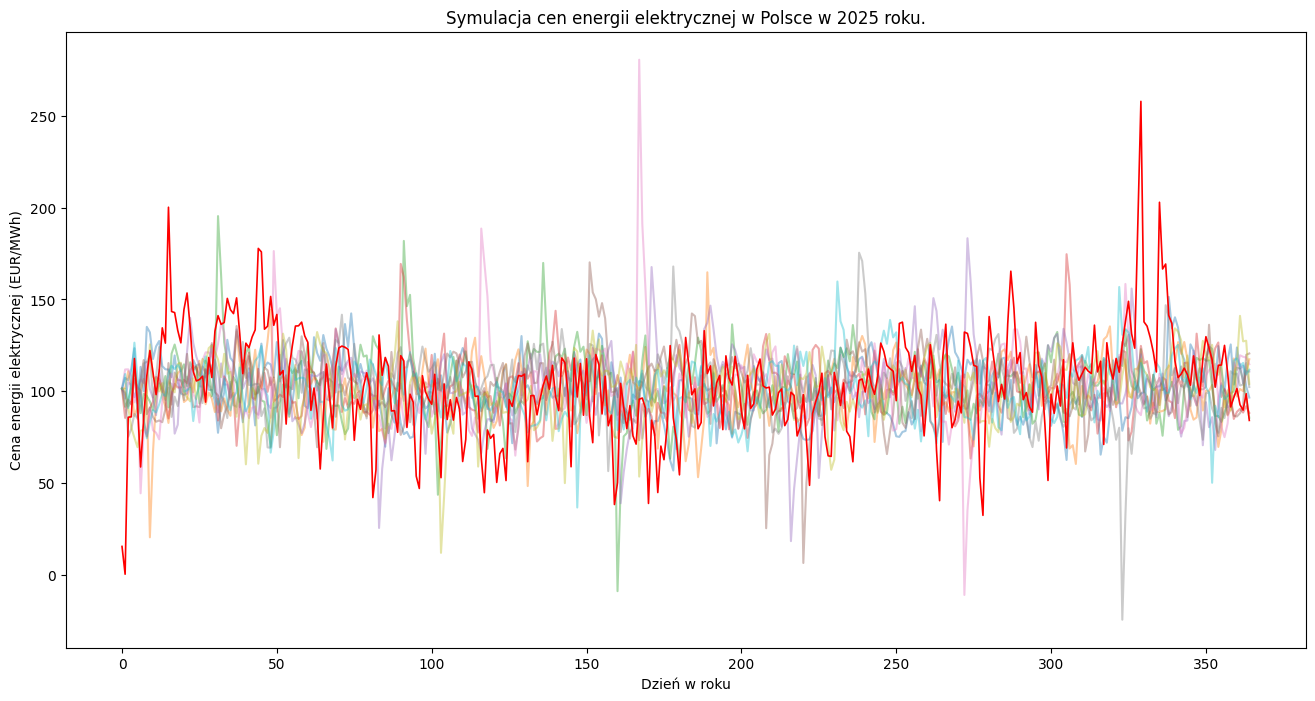

In [19]:
plt.figure(figsize=(16, 8))
for i in range(num_sims):
    plt.plot(sim_prices[:, i], label=f'Symulacja {i+1}', alpha=0.4)
plt.plot(energy_prices_daily.values[:n], label='Średnia dzienna cena energii elektrycznej (dane historyczne)', alpha=1, linewidth=1.2, color='r')
plt.xlabel('Dzień w roku')
plt.ylabel('Cena energii elektrycznej (EUR/MWh)')
plt.title('Symulacja cen energii elektrycznej w Polsce w 2025 roku.')
plt.show()

## Krzywa mocy turbiny
Używam przykładowej krzywej inspirowanej popularnym modelem turbiny Vestas V100-2.0 (https://www.thewindpower.net/turbine_en_779_vestas_v100-2000.php).

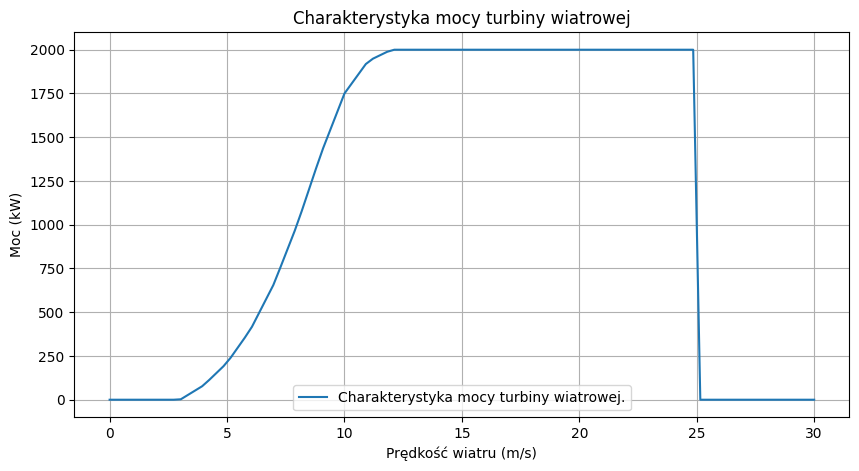

In [20]:
# przykładowa krzywa mocy turbiny wiatrowej 2MW o wysokości 100m
def wind_to_power(wind_speeds):
    xp = [0.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 25.0]
    fp = [0.0, 0.0, 82.0, 211.0, 401.0, 663.0, 1006.0, 1406.0, 1750.0, 1935.0, 2000.0, 2000.0]

    power = np.interp(wind_speeds, xp, fp)
    power = np.where(wind_speeds > 25.0, 0.0, power)

    return power

example = np.linspace(0, 30, 100)
power_example = wind_to_power(example)

plt.figure(figsize=(10, 5))
plt.plot(example, power_example, label='Charakterystyka mocy turbiny wiatrowej.')
plt.xlabel('Prędkość wiatru (m/s)')
plt.ylabel('Moc (kW)')
plt.title('Charakterystyka mocy turbiny wiatrowej')
plt.legend()
plt.grid()
plt.show()

## Symulacja Monte Carlo

Definicja stałych.

In [21]:
NUM_SIMULATIONS = 17500                                         # liczba symulacji Monte Carlo
NUM_YEARS = 6                                                   # liczba lat symulacji

WIND_SAMPLES_PER_YEAR = 8760                                    # liczba próbek wiatru na rok (godzinowe dane)
PRICE_SAMPLES_PER_YEAR = 365                                    # liczba próbek cen energii na rok (dziennie dane)

NUM_TURBINES = 12                                               # liczba turbin wiatrowych w projekcie
TURBINE_WORKING_PROB = 0.92                                     # prawdopodobieństwo, że turbina jest sprawna w danym momencie
TURBINE_CAPACITY = 2.0                                          # moc turbiny [MW]
TOTAL_CAPACITY = NUM_TURBINES * TURBINE_CAPACITY                # całkowita moc projektu [MW]

CAPEX_PER_MW = 1_200_000                                        # koszt inwestycyjny na [€/MW]
TOTAL_CAPACITY_COST = TOTAL_CAPACITY * CAPEX_PER_MW             # całkowity koszt inwestycyjny projektu [€]

ANNUAL_OPEX = 0.02 * TOTAL_CAPACITY_COST                        # roczne koszty operacyjne [€]

DISCOUNT_RATE = 0.08                                            # stopa dyskontowa [% rocznie]


Dla każdej godziny symulacji sporządzam wektor liczby działających turbin wiatrowych.

In [22]:
turbine_availability = BASE_RNG.binomial(n=NUM_TURBINES, p=TURBINE_WORKING_PROB, size=(WIND_SAMPLES_PER_YEAR*NUM_YEARS, NUM_SIMULATIONS))

#print(turbine_availability[:100])

Korzystamy z parametrów **k**, **lam**, **theta**, **mu**, **sigma**, **h** wyestymowanych wcześniej.

In [23]:
# wind_speeds = simulate_wind_speeds(k, lam, num_samples=WIND_SAMPLES_PER_YEAR*NUM_YEARS, num_sims=NUM_SIMULATIONS)
wind_speeds = simulate_autocorelated_wind_speeds(k, lam, num_samples=WIND_SAMPLES_PER_YEAR*NUM_YEARS, num_sims=NUM_SIMULATIONS)
energy_prices = simulate_energy_prices(theta, mu, sigma, PRICE_SAMPLES_PER_YEAR*NUM_YEARS, h, num_sims=NUM_SIMULATIONS)

In [24]:
generated_power = wind_to_power(wind_speeds) * turbine_availability
daily_power = generated_power.reshape(-1, 24, NUM_SIMULATIONS).sum(axis=1)
revenue = daily_power * energy_prices / 1000  

In [25]:
wind_speeds.shape, turbine_availability.shape, energy_prices.shape

((52560, 17500), (52560, 17500), (2190, 17500))

## Podsumowanie wyników

In [26]:
cumulative_revenue = revenue.cumsum(axis=0)
opex = np.arange(1, NUM_YEARS * PRICE_SAMPLES_PER_YEAR + 1) * (ANNUAL_OPEX / PRICE_SAMPLES_PER_YEAR)
opex = opex.reshape(-1, 1)
#print(opex.shape)
cumulative_income = - (opex + TOTAL_CAPACITY_COST) + cumulative_revenue
#print(cumulative_income.shape)

total_revenue = revenue.sum(axis=0)
income = total_revenue - (TOTAL_CAPACITY_COST + ANNUAL_OPEX * NUM_YEARS)
#npv[:10]

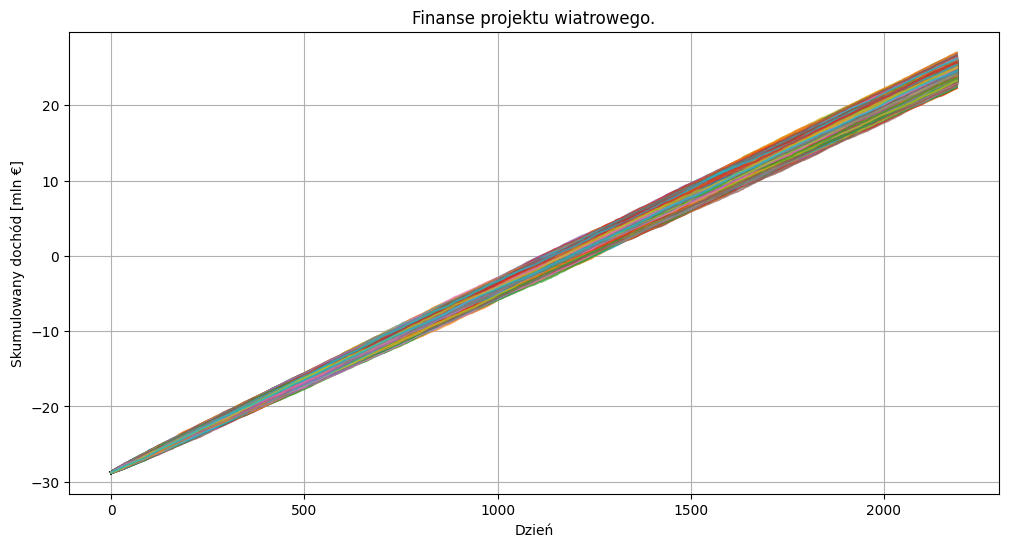

In [27]:
plt.figure(figsize=(12, 6))
plt.plot(cumulative_income/1_000_000, label='Skumulowany dochód (przychód - koszty)', alpha=0.7)
plt.xlabel('Dzień')
plt.ylabel('Skumulowany dochód [mln €]')
plt.title('Finanse projektu wiatrowego.')
plt.grid(True)
plt.show()

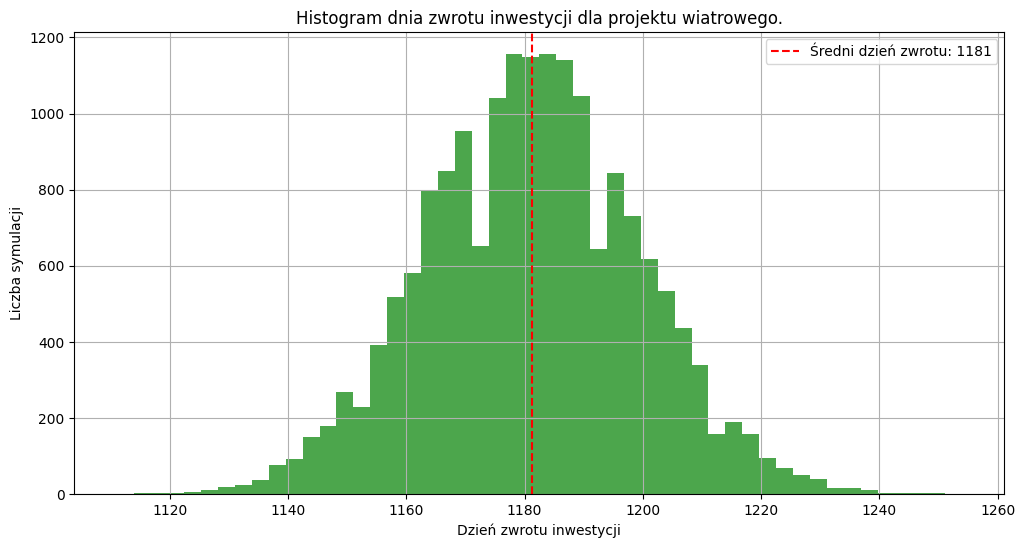

In [28]:
return_day = np.argmax(cumulative_income > 0, axis=0)
plt.figure(figsize=(12, 6))
plt.hist(return_day, bins=50, alpha=0.7, color='g')
plt.axvline(x=np.mean(return_day), color='r', linestyle='--', label=f'Średni dzień zwrotu: {np.mean(return_day):.0f}')
plt.xlabel('Dzień zwrotu inwestycji')
plt.ylabel('Liczba symulacji')
plt.title('Histogram dnia zwrotu inwestycji dla projektu wiatrowego.')
plt.grid(True)
plt.legend()
plt.show()

In [29]:
percentile_2_5 = np.percentile(return_day, 2.5)
percentile_97_5 = np.percentile(return_day, 97.5)
print(f"dzień zwrotu inwestycji 95%: [{percentile_2_5:.0f} - {percentile_97_5:.0f} dni]")

dzień zwrotu inwestycji 95%: [1146 - 1217 dni]


### Net Present Value
$$ NPV = \sum_{t=1}^{n}\frac{CF_t}{(1+r)^t}-C_0 $$
gdzie: $r \text{ - stopa dyskontowa}, \quad CF_t \text{ - przepływy pieniężne w roku }t, \quad C_0 \text{ - początkowy koszt inwestycji}.$ 

In [30]:

annual_revenue = revenue.reshape(NUM_YEARS, 365, -1).sum(axis=1)
annual_cash_flow = annual_revenue - ANNUAL_OPEX
years = np.arange(1, NUM_YEARS + 1).reshape(-1, 1)
discounted_cash_flows = annual_cash_flow / ((1 + DISCOUNT_RATE) ** years)
npv = discounted_cash_flows.cumsum(axis=0) - TOTAL_CAPACITY_COST
#npv[NUM_YEARS - 1].shape

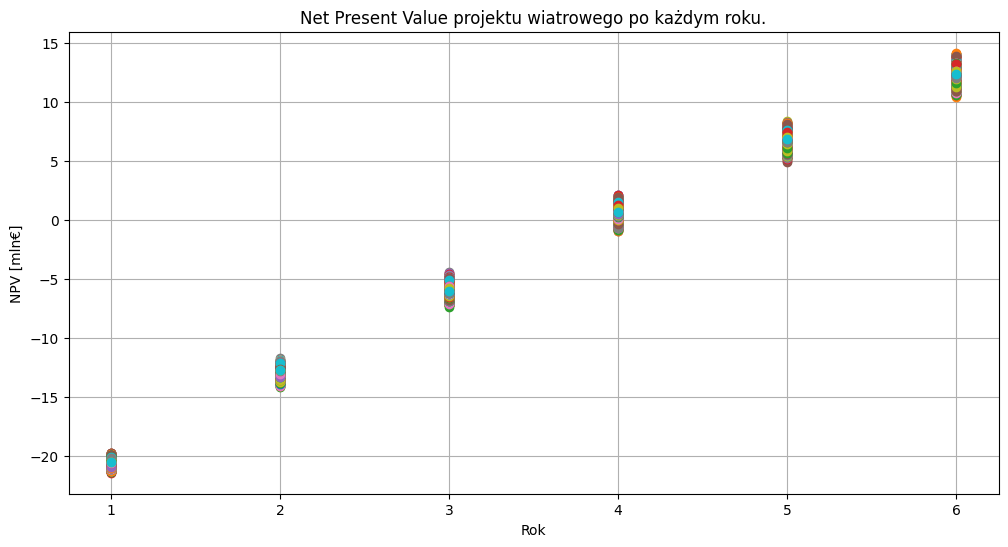

In [31]:
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, NUM_YEARS + 1), npv / 1_000_000, 'o', label='NPV projektu')
plt.xlabel('Rok')
plt.ylabel('NPV [mln€]')
plt.title('Net Present Value projektu wiatrowego po każdym roku.')
plt.grid()
plt.show()

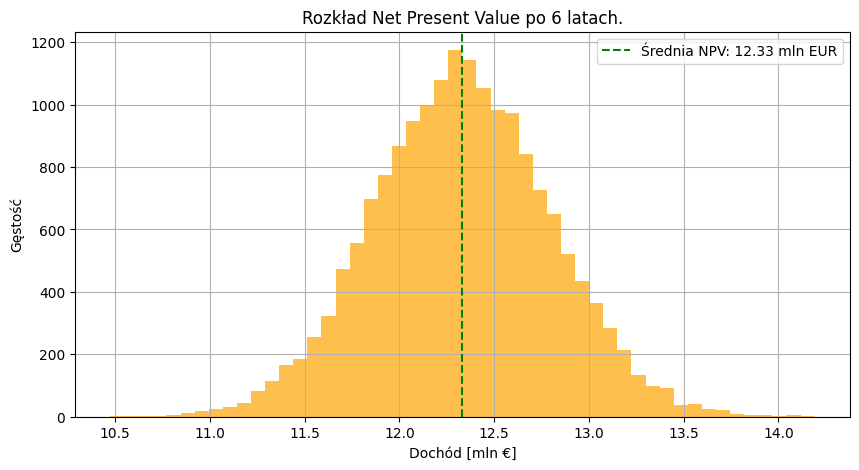

In [32]:
plt.figure(figsize=(10, 5))
#plt.hist(income/ 1_000_000, bins=50, alpha=0.7, label='Symulowane dochody')
plt.hist(npv[NUM_YEARS - 1] / 1_000_000, bins=50, alpha=0.7, color='orange')
plt.axvline(x=np.mean(npv[NUM_YEARS - 1])/ 1_000_000, color='g', linestyle='--', label=f'Średnia NPV: {np.mean(npv[NUM_YEARS - 1])/ 1_000_000:.2f} mln EUR')
plt.xlabel('Dochód [mln €]')
plt.ylabel('Gęstość')
plt.title(f'Rozkład Net Present Value po {NUM_YEARS} latach.')
plt.legend()
plt.grid()
plt.show()

In [33]:
percentile_2_5 = np.percentile(npv[NUM_YEARS-1], 2.5)
percentile_97_5 = np.percentile(npv[NUM_YEARS-1], 97.5)
print(f"npv 95%: [{percentile_2_5/ 1_000_000:.2f} mln EUR - {percentile_97_5/ 1_000_000:.2f} mln EUR]")

npv 95%: [11.42 mln EUR - 13.24 mln EUR]


In [34]:
for i in range(NUM_YEARS):
    loss_propability = (npv[i] < 0).mean()
    print(f"Prawdopodobieństwo straty po {i+1} latach: {loss_propability:.2%}")

Prawdopodobieństwo straty po 1 latach: 100.00%
Prawdopodobieństwo straty po 2 latach: 100.00%
Prawdopodobieństwo straty po 3 latach: 100.00%
Prawdopodobieństwo straty po 4 latach: 5.01%
Prawdopodobieństwo straty po 5 latach: 0.00%
Prawdopodobieństwo straty po 6 latach: 0.00%
